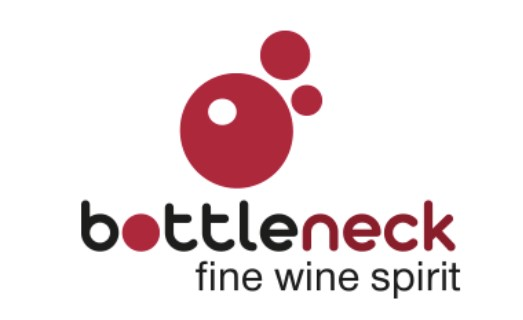

# **Optimisation de la gestion des données**

## **Importation de données**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import scipy.stats as stats
import seaborn as sns
warnings.simplefilter(action='ignore', category=UserWarning)

In [2]:
web = pd.read_excel("web.xlsx")
erp = pd.read_excel("erp.xlsx")
liaison = pd.read_excel("liaison.xlsx")

## **Vérification de l'information contenue dans les tableaux**

In [3]:
erp.head(5)

,product_id,onsale_web,price,stock_quantity,stock_status
0,3847,1,24.2,0,outofstock
1,3849,1,34.3,0,outofstock
2,3850,1,20.8,0,outofstock
3,4032,1,14.1,0,outofstock
4,4039,1,46.0,0,outofstock


In [4]:
erp.isnull().sum()

product_id        0
onsale_web        0
price             0
stock_quantity    0
stock_status      0
dtype: int64

In [5]:
liaison.columns = ['product_id', 'sku']
liaison.head(5)

,product_id,sku
0,3847,15298
1,3849,15296
2,3850,15300
3,4032,19814
4,4039,19815


### **La colonne id_web a été renomé 'sku' pour faciliter le traitment de l'information**

In [6]:
liaison.isnull().sum()

product_id     0
sku           91
dtype: int64

In [7]:
web.head(5)

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,...,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
0,bon-cadeau-25-euros,0,0,0,0.0,10.0,taxable,NaN,1.0,2018-06-01 13:53:46,...,bon-cadeau-de-25-euros,2018-06-01 14:13:57,2018-06-01 12:13:57,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
1,15298,0,0,0,0.0,6.0,taxable,NaN,2.0,2018-02-08 12:58:52,...,pierre-jean-villa-saint-joseph-preface-2018,2019-12-30 09:30:29,2019-12-30 08:30:29,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
2,15296,0,0,0,0.0,0.0,taxable,NaN,2.0,2018-02-08 13:49:41,...,pierre-jean-villa-saint-joseph-tilde-2017,2019-12-21 09:00:17,2019-12-21 08:00:17,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
3,15300,0,0,0,0.0,0.0,taxable,NaN,2.0,2018-02-08 14:08:36,...,pierre-jean-villa-croze-hermitage-accroche-coe...,2020-06-26 18:15:03,2020-06-26 16:15:03,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
4,19814,0,0,0,0.0,3.0,taxable,NaN,2.0,2018-02-09 14:01:05,...,pierre-jean-villa-igp-gamine-2018,2020-01-04 16:36:01,2020-01-04 15:36:01,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


In [9]:
web.isnull().sum()

sku                        85
virtual                     0
downloadable                0
rating_count                0
average_rating             83
total_sales                83
tax_status                797
tax_class                1513
post_author                83
post_date                  83
post_date_gmt              83
post_content             1513
post_title                 83
post_excerpt              797
post_status                83
comment_status             83
ping_status                83
post_password            1513
post_name                  83
post_modified              83
post_modified_gmt          83
post_content_filtered    1513
post_parent                83
guid                       83
menu_order                 83
post_type                  83
post_mime_type            799
comment_count              83
dtype: int64

In [10]:
web.loc[web['sku'].isnull()]

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,...,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
178,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
179,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
227,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
230,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
231,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
792,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
793,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
794,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
795,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
web[(web['post_name'].notnull()) & (web['sku'].isna())]

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,...,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
470,NaN,0,0,0,0.0,0.0,taxable,NaN,2.0,2018-07-31 12:07:23,...,pierre-jean-villa-cote-rotie-fongeant-2017,2019-11-02 13:24:15,2019-11-02 12:24:15,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
471,NaN,0,0,0,0.0,0.0,taxable,NaN,2.0,2018-08-08 11:23:43,...,pierre-jean-villa-condrieu-suspendu-2018,2019-11-02 13:24:01,2019-11-02 12:24:01,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


### **Il existe deux lignes avec des renseignements mais sans sku, donc il faudrait chercher l'information manquante pour pouvoir travailler ces deux lignes**

In [12]:
web = web.loc[web['post_type'] == 'product']

In [13]:
web = web[web['sku'].notna()]

In [14]:
web.loc[web['sku'].isna()]

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,...,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count


In [15]:
web.shape

(714, 28)

## **Union des trois tableaux**

In [16]:
df_web_liaison = pd.merge(erp, liaison, how = 'outer', on = 'product_id', indicator= True)
df_web_liaison.head()

,product_id,onsale_web,price,stock_quantity,stock_status,sku,_merge
0,3847,1,24.2,0,outofstock,15298,both
1,3849,1,34.3,0,outofstock,15296,both
2,3850,1,20.8,0,outofstock,15300,both
3,4032,1,14.1,0,outofstock,19814,both
4,4039,1,46.0,0,outofstock,19815,both


In [17]:
df_web_liaison['_merge'].value_counts()

both          825
left_only       0
right_only      0
Name: _merge, dtype: int64

In [18]:
#web_liaison.drop(['_merge'], axis=1)

In [19]:
df_merge = pd.merge(df_web_liaison.drop('_merge', axis=1), web, how = 'outer', left_on = 'sku', right_on = 'sku', indicator= True)
df_merge.head()

,product_id,onsale_web,price,stock_quantity,stock_status,sku,virtual,downloadable,rating_count,average_rating,...,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,_merge
0,3847,1,24.2,0,outofstock,15298,0.0,0.0,0.0,0.0,...,2019-12-30 09:30:29,2019-12-30 08:30:29,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both
1,3849,1,34.3,0,outofstock,15296,0.0,0.0,0.0,0.0,...,2019-12-21 09:00:17,2019-12-21 08:00:17,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both
2,3850,1,20.8,0,outofstock,15300,0.0,0.0,0.0,0.0,...,2020-06-26 18:15:03,2020-06-26 16:15:03,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both
3,4032,1,14.1,0,outofstock,19814,0.0,0.0,0.0,0.0,...,2020-01-04 16:36:01,2020-01-04 15:36:01,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both
4,4039,1,46.0,0,outofstock,19815,0.0,0.0,0.0,0.0,...,2020-01-04 16:36:10,2020-01-04 15:36:10,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both


In [20]:
df_merge['_merge'].value_counts()

both          714
left_only     111
right_only      0
Name: _merge, dtype: int64

### **Les lignes sans correspondance ne seront pas prises en compte puisqu'elles sont surement des produits pas vendus en ligne** 

In [21]:
df_merge = df_merge[df_merge['_merge'] == 'both']
df_merge

,product_id,onsale_web,price,stock_quantity,stock_status,sku,virtual,downloadable,rating_count,average_rating,...,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,_merge
0,3847,1,24.2,0,outofstock,15298,0.0,0.0,0.0,0.0,...,2019-12-30 09:30:29,2019-12-30 08:30:29,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both
1,3849,1,34.3,0,outofstock,15296,0.0,0.0,0.0,0.0,...,2019-12-21 09:00:17,2019-12-21 08:00:17,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both
2,3850,1,20.8,0,outofstock,15300,0.0,0.0,0.0,0.0,...,2020-06-26 18:15:03,2020-06-26 16:15:03,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both
3,4032,1,14.1,0,outofstock,19814,0.0,0.0,0.0,0.0,...,2020-01-04 16:36:01,2020-01-04 15:36:01,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both
4,4039,1,46.0,0,outofstock,19815,0.0,0.0,0.0,0.0,...,2020-01-04 16:36:10,2020-01-04 15:36:10,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
819,6930,1,8.4,83,instock,16135,0.0,0.0,0.0,0.0,...,2020-08-26 17:35:03,2020-08-26 15:35:03,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both
820,7023,1,27.5,15,instock,15891,0.0,0.0,0.0,0.0,...,2020-08-26 17:35:02,2020-08-26 15:35:02,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both
821,7025,1,69.0,2,instock,15887,0.0,0.0,0.0,0.0,...,2020-08-14 18:15:03,2020-08-14 16:15:03,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both
822,7247,1,54.8,23,instock,13127-1,0.0,0.0,0.0,0.0,...,2020-07-20 17:09:06,2020-07-20 15:09:06,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both


In [22]:
df_merge.shape

(714, 34)

In [23]:
df_merge['rating_count'].unique()

array([0.])

In [24]:
df_merge['average_rating'].unique()

array([0.])

## **Élimination des colonnes inutiles**

In [25]:
del df_merge['onsale_web']
del df_merge['virtual']
del df_merge['downloadable']
del df_merge['rating_count']
del df_merge['average_rating']
del df_merge['tax_class']
del df_merge['post_author']
del df_merge['post_date_gmt']
del df_merge['post_content']
del df_merge['post_status']
del df_merge['comment_status']
del df_merge['ping_status']
del df_merge['post_password']
del df_merge['post_modified_gmt']
del df_merge['post_content_filtered']
del df_merge['post_parent']
del df_merge['guid']
del df_merge['menu_order']
del df_merge['post_mime_type']
del df_merge['comment_count']

In [26]:
df_merge.head()

,product_id,price,stock_quantity,stock_status,sku,total_sales,tax_status,post_date,post_title,post_excerpt,post_name,post_modified,post_type,_merge
0,3847,24.2,0,outofstock,15298,6.0,taxable,2018-02-08 12:58:52,Pierre Jean Villa Saint-Joseph Préface 2018,"Il exhale un nez subtil, racé avec du poivre f...",pierre-jean-villa-saint-joseph-preface-2018,2019-12-30 09:30:29,product,both
1,3849,34.3,0,outofstock,15296,0.0,taxable,2018-02-08 13:49:41,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,Les vieilles vignes lui apportent une rare pro...,pierre-jean-villa-saint-joseph-tilde-2017,2019-12-21 09:00:17,product,both
2,3850,20.8,0,outofstock,15300,0.0,taxable,2018-02-08 14:08:36,Pierre Jean Villa Crozes-Hermitage Accroche Co...,"Dentelle de fruit de jeunes syrah, aux tanins ...",pierre-jean-villa-croze-hermitage-accroche-coe...,2020-06-26 18:15:03,product,both
3,4032,14.1,0,outofstock,19814,3.0,taxable,2018-02-09 14:01:05,Pierre Jean Villa IGP Collines Rhodaniennes Ga...,Gamine représente tout le fruité et la gourman...,pierre-jean-villa-igp-gamine-2018,2020-01-04 16:36:01,product,both
4,4039,46.0,0,outofstock,19815,0.0,taxable,2018-02-12 09:04:37,Pierre Jean Villa Côte Rôtie Carmina 2017,Le côte rôtie Carmina monte en puissance mais ...,pierre-jean-villa-cote-rotie-carmina-2017,2020-01-04 16:36:10,product,both


## **Nettoyage des données**
### Erreurs de type

In [27]:
df_merge.dtypes

product_id                 int64
price                    float64
stock_quantity             int64
stock_status              object
sku                       object
total_sales              float64
tax_status                object
post_date         datetime64[ns]
post_title                object
post_excerpt              object
post_name                 object
post_modified     datetime64[ns]
post_type                 object
_merge                  category
dtype: object

### **Les types de données sont corrects pour cet étude**

### Doublons

In [28]:
df_merge.loc[df_merge['product_id'].duplicated(keep=False),:].head()

,product_id,price,stock_quantity,stock_status,sku,total_sales,tax_status,post_date,post_title,post_excerpt,post_name,post_modified,post_type,_merge


In [29]:
df_merge.duplicated('product_id').sum()

0

In [30]:
df_merge.duplicated('sku').sum()

0

In [31]:
df_merge.loc[df_merge['sku'].duplicated(keep=False),:].head()

,product_id,price,stock_quantity,stock_status,sku,total_sales,tax_status,post_date,post_title,post_excerpt,post_name,post_modified,post_type,_merge


In [32]:
# on compte le nombre de valeurs manquantes pour la ligne et on stocke dans une nouvelle colonne
df_merge['NB_NAN'] = df_merge.isna().sum(axis=1)
# trie des lignes en fonction du nombre de valeurs manquantes
df_merge = df_merge.sort_values('NB_NAN')
# suppression des duplicatas en gardant les versions les mieux remplies
df_merge = df_merge.drop_duplicates(subset=['product_id', 'price', 'stock_quantity', 'sku', 'post_date', 'post_title', 'post_name', 'post_type'], keep='first')
# on supprime la colonne qui n'est plus utile
df_merge = df_merge.drop('NB_NAN', axis=1)

In [33]:
df_merge.shape

(714, 14)

### Valeurs manquantes


In [34]:
df_merge.isnull().sum()

product_id        0
price             0
stock_quantity    0
stock_status      0
sku               0
total_sales       0
tax_status        0
post_date         0
post_title        0
post_excerpt      0
post_name         0
post_modified     0
post_type         0
_merge            0
dtype: int64

In [35]:
df_merge.loc[df_merge['sku'].isnull(),:]

,product_id,price,stock_quantity,stock_status,sku,total_sales,tax_status,post_date,post_title,post_excerpt,post_name,post_modified,post_type,_merge


#### **Les valeurs NA dans la colonne sku seront conservées car quoiqu'ils n'aient pas un sku ils ont un produit ID et une quantité en stock. Donc le prochain pas sera de compléter cette information auprès du département de gestion de produits**

### Détection d'outliers

In [36]:
df_merge.describe(include=['O'])

,stock_status,sku,tax_status,post_title,post_excerpt,post_name,post_type
count,714,714,714,714,714,714,714
unique,2,714,1,711,677,714,1
top,instock,15298,taxable,Marc Colin Et Fils Chassagne-Montrachet Blanc ...,Les eaux de vie naissent d'une subtile alchimi...,pierre-jean-villa-saint-joseph-preface-2018,product
freq,574,1,714,2,12,1,714


In [37]:
df_merge.describe()

,product_id,price,stock_quantity,total_sales
count,714.000000,714.000000,714.000000,714.000000
mean,5032.557423,32.493137,28.746499,4.012605
std,790.510878,27.810525,48.012608,8.518183
min,3847.000000,5.200000,0.000000,0.000000
25%,4280.250000,14.100000,2.000000,0.000000
50%,4796.000000,23.550000,12.000000,1.000000
75%,5710.500000,42.175000,35.000000,4.000000
max,7338.000000,225.000000,578.000000,96.000000


### **Pour les prix:**

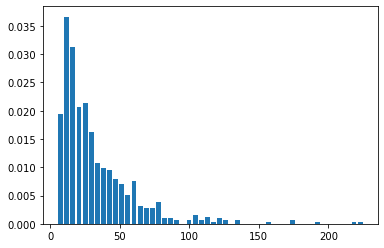

In [38]:
plt.hist(df_merge.price, bins = 50, rwidth = .8, density = True)
plt.show()

In [39]:
df_merge['price'].describe()

count    714.000000
mean      32.493137
std       27.810525
min        5.200000
25%       14.100000
50%       23.550000
75%       42.175000
max      225.000000
Name: price, dtype: float64

### Estimation z-score

In [40]:
df_merge['zscore']=stats.zscore(df_merge['price'])
df_merge.head()

,product_id,price,stock_quantity,stock_status,sku,total_sales,tax_status,post_date,post_title,post_excerpt,post_name,post_modified,post_type,_merge,zscore
0,3847,24.2,0,outofstock,15298,6.0,taxable,2018-02-08 12:58:52,Pierre Jean Villa Saint-Joseph Préface 2018,"Il exhale un nez subtil, racé avec du poivre f...",pierre-jean-villa-saint-joseph-preface-2018,2019-12-30 09:30:29,product,both,-0.298410
571,5474,42.0,0,outofstock,14679,4.0,taxable,2018-10-09 14:05:15,Domaine Saint-Nicolas Fiefs Vendéens Rouge La ...,Grande Pièce est un rouge d'une grande nobless...,domaine-saint-nicolas-fiefs-vendeens-rouge-gra...,2020-03-14 11:45:02,product,both,0.342084
572,5477,19.8,38,instock,15526,4.0,taxable,2018-10-09 14:21:32,Domaine Pellé Menetou Salon Blanc Les Vignes d...,"La cuvée Vignes de Ratier est un grand blanc, ...",pelle-menetou-salon-blanc-ratier-2018,2020-08-26 15:55:03,product,both,-0.456735
573,5479,10.2,69,instock,16305,3.0,taxable,2018-10-09 14:32:21,Domaine Bulliat Beaujolais Blanc 2019,Un joli beaujolais blanc tout en gourmandise e...,domaine-bulliat-beaujolais-blanc-2019,2020-08-25 18:25:04,product,both,-0.802170
574,5480,10.4,37,instock,16306,1.0,taxable,2018-10-09 14:43:02,Domaine Bulliat Chiroubles Cuvée Félix 2019,"Un très joli Chiroubles, souple, élégant et tr...",domaine-bulliat-chiroubles-2019,2020-08-25 15:05:03,product,both,-0.794973


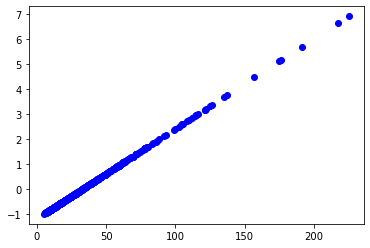

In [41]:
x = df_merge['price']
y = df_merge['zscore']
plt.scatter(x, y, c ="blue")
plt.show()

In [42]:
df_merge['zscore'].describe()

count    7.140000e+02
mean    -3.871786e-17
std      1.000701e+00
min     -9.820840e-01
25%     -6.618369e-01
50%     -3.217993e-01
75%      3.483807e-01
max      6.926939e+00
Name: zscore, dtype: float64

In [43]:
a= df_merge[(df_merge.zscore > -2) & (df_merge.zscore < 2)]

In [44]:
totaloutliers = df_merge.shape[0] - a.shape[0]
print('Total outliers:', totaloutliers)

Total outliers: 30


In [45]:
z = np.abs(stats.zscore(df_merge['price']))
Limite = 2
 # Liste des Outliers
    
listeoutliers = np.where(z > 2)
print("Liste d'outliers:", listeoutliers)

Liste d'outliers: (array([ 66,  77,  90,  98, 134, 139, 140, 145, 183, 184, 185, 186, 187,
       188, 199, 216, 306, 321, 332, 333, 340, 513, 531, 641, 642, 645,
       647, 667, 669, 695], dtype=int64),)


In [46]:
df_merge.loc[df_merge['price']>85.6,:].sort_values('price')

,product_id,price,stock_quantity,stock_status,sku,total_sales,tax_status,post_date,post_title,post_excerpt,post_name,post_modified,post_type,_merge,zscore
539,5026,86.8,2,instock,13913,0.0,taxable,2018-07-18 10:46:30,Champagne Agrapart &amp; Fils Minéral Extra Br...,"Légèrement praliné au nez, nerveux, frais, inc...",champagne-agrapart-fils-mineral-extra-brut-bla...,2020-05-11 14:35:02,product,both,1.954114
156,4132,88.4,5,instock,11668,0.0,taxable,2018-02-13 11:43:55,Zind-Humbrecht Pinot Gris Grand Cru Rangen De ...,Le nez dévoile déjà une belle intensité de fru...,zind-humbrecht-pinot-gris-grand-cru-rangen-de-...,2020-02-20 09:55:02,product,both,2.011686
605,5565,92.0,0,outofstock,19822,0.0,taxable,2018-11-26 10:59:10,Tempier Bandol Cabassaou 2017,"<div id=""wrapper"">\n<div id=""container-wrapper...",tempier-bandol-cabassaou-2017,2020-01-04 13:57:04,product,both,2.141225
707,5916,93.0,3,instock,14774,0.0,taxable,2019-04-04 16:39:24,Wemyss Malts Single Cask Scotch Whisky Chocola...,"305 bouteilles, 13 ans d'âge.\n\n<span title=""...",wemyss-malts-single-cask-chocolate-moka-cake,2019-12-23 09:30:21,product,both,2.177207
765,6214,99.0,7,instock,11601,0.0,taxable,2019-07-25 09:15:41,Domaine des Comtes Lafon Volnay 1er Cru Champa...,La couleur rouge intense annonce un belle conc...,domaine-des-comtes-lafon-volnay-1er-cru-champa...,2020-07-04 11:35:02,product,both,2.393104
154,4115,100.0,11,instock,15382,0.0,taxable,2018-02-13 11:08:45,Zind-Humbrecht Riesling Grand Cru Rangen De Th...,"Le nez est puissant, dominant, riche, sur la f...",zind-humbrecht-riesling-gc-rangen-thann-clos-s...,2020-02-08 11:45:02,product,both,2.429087
477,4903,102.3,20,instock,14805,0.0,taxable,2018-05-15 10:10:57,Domaine Des Croix Corton Grand Cru Les Grèves ...,Ce vin exhale de beaux arômes de fruits rouges...,domaine-des-croix-corton-grand-cru-les-greves-...,2020-06-27 09:00:07,product,both,2.511848
314,4407,104.0,6,instock,3509,1.0,taxable,2018-03-22 11:49:53,Cognac Frapin Cigar Blend,Ce cognac bénéficie d'un vieillissement plus l...,cognac-frapin-cigar-blend,2020-07-04 09:45:03,product,both,2.573018
530,5007,105.0,17,instock,12791,0.0,taxable,2018-07-17 10:36:03,Domaine des Comtes Lafon Volnay 1er Cru Santen...,"""Il s'agit là de la meilleure partie de l'appe...",domaine-des-comtes-lafon-volnay-1er-cru-santen...,2020-07-02 09:30:03,product,both,2.609001
531,5008,105.0,10,instock,11602,0.0,taxable,2018-07-17 10:52:41,Domaine des Comtes Lafon Volnay 1er Cru Santen...,"""Il s'agit là de la meilleure partie de l'appe...",domaine-des-comtes-lafon-volnay-1er-cru-santen...,2020-06-23 15:35:02,product,both,2.609001


### **Après vérification des deux prix supérieurs à 200 EUR, il s'est avéré qu'en effet ces prix correspondent à l'information trouvé sur internet donc, les prix sont bien réels**

https://www.drinksco.fr/vin-chambertin/david-duband-chambertin-grand-cru-2014?shop=cave-littlewood&utm_medium=web&utm_campaign=marketplaces&gaw=1&gclid=CjwKCAjwwdWVBhA4EiwAjcYJEBbMUfo8QhI0NcRWq9acwJAlcpiCg1Z-cddXEGI9gBZkGp7q07FL7xoCHo0QAvD_BwE

https://www.premiersgrandscrus.com/fr/champagne/1089-egly-ouriet-millesime-2007-champagne-grand-cru.html?SubmitCurrency=1&id_currency=1&gclid=CjwKCAjwwdWVBhA4EiwAjcYJEEELD6oKsNsTjAjjt-0nQtPS-GOXgNzWcz5bd7R3LGT9-4gwtNKPHRoCiPUQAvD_BwE

### Estimation Ecart Interquartile  

In [47]:
q75, q25 = np.percentile(df_merge['price'], [75 ,25])
iqr = q75 - q25
iqr


28.075000000000003

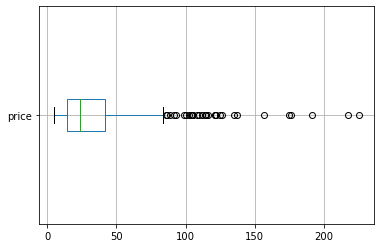

In [48]:
df_merge.boxplot(column="price", vert=False)
plt.show()

In [49]:
Q1 = df_merge['price'].quantile(.25)
Q3 = df_merge['price'].quantile(.75)
EIQ = Q3 - Q1
min_value = Q1 - 1.5 * EIQ
max_value = Q3 + 1.5 * EIQ

outlier = []
total = 0 
for i in df_merge['price']:
    if ((i> max_value) or (i<min_value)):
        outlier.append(i)
        total = 1 + total
print(' outlier in the dataset is', outlier)
print('Total outliers:', total)

 outlier in the dataset is [124.8, 92.0, 137.0, 102.3, 217.5, 105.0, 105.0, 112.0, 86.8, 115.0, 121.0, 99.0, 115.0, 116.4, 121.0, 105.6, 135.0, 175.0, 114.0, 122.0, 93.0, 191.3, 88.4, 100.0, 85.6, 176.0, 108.5, 126.5, 225.0, 157.0, 104.0, 109.6]
Total outliers: 32


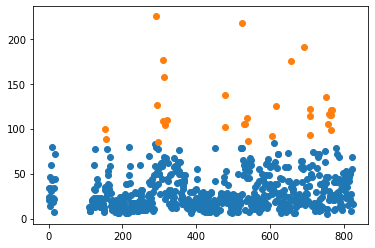

In [50]:
plt.scatter(df_merge[(df_merge['price'] < 85.6)].index, df_merge[(df_merge['price'] < 85.6)].price)
plt.scatter(df_merge[(df_merge['price'] >= 85.6)].index, df_merge[(df_merge['price'] >= 85.6)].price)

### **Pour le stock:**

In [51]:
df_merge['stock_quantity'].describe()

count    714.000000
mean      28.746499
std       48.012608
min        0.000000
25%        2.000000
50%       12.000000
75%       35.000000
max      578.000000
Name: stock_quantity, dtype: float64

### Estimation Ecart Interquartile  

In [52]:
q75, q25 = np.percentile(df_merge['stock_quantity'], [75 ,25])
iqr = q75 - q25
iqr



33.0

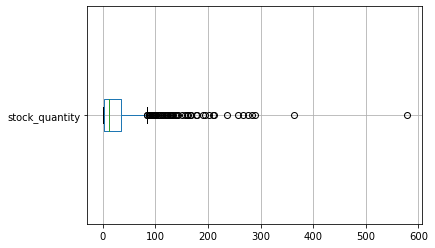

In [53]:
df_merge.boxplot(column="stock_quantity", vert=False)
plt.show()

### **Nous remarquons deux valeurs très eloignés du reste**

In [54]:
produit_chers = df_merge.loc[df_merge['stock_quantity']>200,:].sort_values('stock_quantity')
produit_chers.shape

(11, 15)

In [55]:
produit_chers['Stock_value']=produit_chers['price']*produit_chers['stock_quantity']

In [56]:
produit_chers[['product_id', 'stock_quantity', 'total_sales', 'Stock_value']]

,product_id,stock_quantity,total_sales,Stock_value
513,4965,203,26.0,1441.3
203,4191,209,12.0,1943.7
666,5779,211,8.0,1223.8
333,4609,237,0.0,2796.6
454,4858,257,1.0,1670.5
112,4058,267,11.0,2322.9
191,4176,276,9.0,3726.0
456,4861,284,29.0,2414.0
511,4963,289,2.0,2023.0
762,6207,363,37.0,9147.6


### **Il est recommandé de vérifier dans le dépôt la quantité de stock. Si ces deux quantités sont réelles cela repressentirait 13540 EUR en Stock**

## Analyse des données

### **Estimation du total de ventes du 2018 à 2020**

In [57]:
df_merge['amount_per_product'] = df_merge['price']* df_merge['total_sales']
df_merge.head(3)

,product_id,price,stock_quantity,stock_status,sku,total_sales,tax_status,post_date,post_title,post_excerpt,post_name,post_modified,post_type,_merge,zscore,amount_per_product
0,3847,24.2,0,outofstock,15298,6.0,taxable,2018-02-08 12:58:52,Pierre Jean Villa Saint-Joseph Préface 2018,"Il exhale un nez subtil, racé avec du poivre f...",pierre-jean-villa-saint-joseph-preface-2018,2019-12-30 09:30:29,product,both,-0.298410,145.2
571,5474,42.0,0,outofstock,14679,4.0,taxable,2018-10-09 14:05:15,Domaine Saint-Nicolas Fiefs Vendéens Rouge La ...,Grande Pièce est un rouge d'une grande nobless...,domaine-saint-nicolas-fiefs-vendeens-rouge-gra...,2020-03-14 11:45:02,product,both,0.342084,168.0
572,5477,19.8,38,instock,15526,4.0,taxable,2018-10-09 14:21:32,Domaine Pellé Menetou Salon Blanc Les Vignes d...,"La cuvée Vignes de Ratier est un grand blanc, ...",pelle-menetou-salon-blanc-ratier-2018,2020-08-26 15:55:03,product,both,-0.456735,79.2


In [58]:
total_ventes_historique = df_merge['amount_per_product'].sum()
print('Le total de ventes entre 2018 et 2020 est de: ', total_ventes_historique)

Le total de ventes entre 2018 et 2020 est de:  70568.6


### **Estimation du total de ventes du 2018 à 2020 par produit**

In [59]:
df_merge.groupby(['product_id']).sum().sort_values('amount_per_product', ascending=False)

,price,stock_quantity,total_sales,zscore,amount_per_product
product_id,,,,,
4334,49.0,0,96.0,0.593963,4704.0
4144,49.0,11,87.0,0.593963,4263.0
4402,176.0,8,13.0,5.163781,2288.0
4142,53.0,8,30.0,0.737895,1590.0
4141,39.0,1,40.0,0.234135,1560.0
...,...,...,...,...,...
4791,13.6,24,0.0,-0.679828,0.0
4790,11.1,43,0.0,-0.769785,0.0
4786,12.1,37,0.0,-0.733803,0.0


In [60]:
df_merge.groupby(['product_id'])['amount_per_product'].sum().sort_values(ascending=False).head(5)

product_id
4334    4704.0
4144    4263.0
4402    2288.0
4142    1590.0
4141    1560.0
Name: amount_per_product, dtype: float64

### **Analyse des corrélations**

In [61]:
df_merge[['price','total_sales']].corr()

,price,total_sales
price,1.000000,-0.133353
total_sales,-0.133353,1.000000


In [62]:
df_merge.corr()

,product_id,price,stock_quantity,total_sales,zscore,amount_per_product
product_id,1.000000,0.140821,-0.118526,-0.179147,0.140821,-0.132969
price,0.140821,1.000000,-0.293144,-0.133353,1.000000,0.152342
stock_quantity,-0.118526,-0.293144,1.000000,0.273654,-0.293144,0.023190
total_sales,-0.179147,-0.133353,0.273654,1.000000,-0.133353,0.796237
zscore,0.140821,1.000000,-0.293144,-0.133353,1.000000,0.152342
amount_per_product,-0.132969,0.152342,0.023190,0.796237,0.152342,1.000000


In [63]:
df_merge['categories_price'] = pd.qcut(df_merge['price'], 4, duplicates='drop')
df_merge['categories_sales'] = pd.qcut(df_merge['total_sales'], 4, duplicates='drop')
pd.crosstab(df_merge['categories_price'], df_merge['categories_sales'])

categories_sales,"(-0.001, 1.0]","(1.0, 4.0]","(4.0, 96.0]"
categories_price,,,
"(5.199, 14.1]",75,33,73
"(14.1, 23.55]",94,36,46
"(23.55, 42.175]",110,31,37
"(42.175, 225.0]",137,22,20


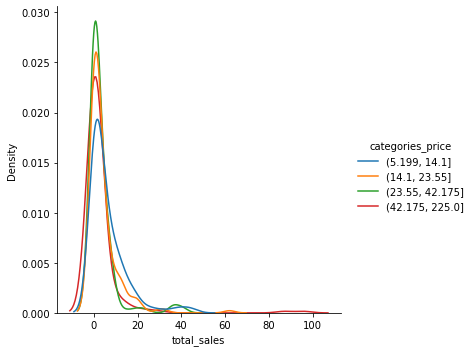

In [64]:
sns.displot(data=df_merge, x="total_sales", hue="categories_price", kind="kde")

### **Conclusion : Nous remarquons un très faible correlation entre le prix et la quantité de produits vendus**